In [ ]:
!pip install --quiet networkx matplotlib numpy

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random


In [ ]:
G = nx.Graph()

floors = 3
x_rooms = 4
y_rooms = 3

# Updated spacings
room_spacing_x = 24
room_spacing_y = 26
floor_spacing_z = 15  # vertical spacing between floors

room_ids = {}

for z in range(floors):
    for y in range(y_rooms):
        for x in range(x_rooms):
            room_num = z * 100 + 101 + (y * x_rooms + x)
            node_id = str(room_num)

            G.add_node(node_id,
                       type="room",
                       x=x * room_spacing_x,
                       y=y * room_spacing_y,
                       z=z * floor_spacing_z,  # this is the vertical separation
                       structural_integrity=1.0,
                       urgency=0.0,
                       gas_leak=False,
                       occupants=0,
                       trust_level=1.0)

            room_ids[(x, y, z)] = node_id



In [ ]:
# Connect horizontal (E/W) rooms in each row
for z in range(floors):
    for y in range(y_rooms):
        for x in range(x_rooms - 1):
            n1 = room_ids[(x, y, z)]
            n2 = room_ids[(x + 1, y, z)]
            G.add_edge(n1, n2,
                       edge_type="hallway",
                       status="open",
                       distance=room_spacing_x,
                       trust_score=1.0,
                       structural_risk=0.0)
            if random.random() < 0.15:
                G[n1][n2]["hazard"] = "debris"

# Connect vertical (N/S) outer columns only: left column (x=0), right column (x=3)
outer_cols = [0, x_rooms - 1]

for z in range(floors):
    for x in outer_cols:
        for y in range(y_rooms - 1):
            n1 = room_ids[(x, y, z)]
            n2 = room_ids[(x, y + 1, z)]
            G.add_edge(n1, n2,
                       edge_type="hallway",
                       status="open",
                       distance=room_spacing_y,
                       trust_score=1.0,
                       structural_risk=0.0)
            if random.random() < 0.15:  # ADD THIS LINE
                G[n1][n2]["hazard"] = "debris"



In [ ]:
floor_height = floor_spacing_z  # use the spacing that matches your Z coordinate

# Elevator in front-left corner (x=0, y=0)
elevator_stack = [(0, 0)]

# Stairs ONLY in back right corner
stair_stack = [(3,2)]

# Elevator edges
for x, y in elevator_stack:
    for z in range(floors - 1):
        if (x, y, z) in room_ids and (x, y, z + 1) in room_ids:
            n1 = room_ids[(x, y, z)]
            n2 = room_ids[(x, y, z + 1)]
            G.add_edge(n1, n2,
                       edge_type="elevator",
                       status="open",
                       distance=floor_height,
                       trust_score=1.0,
                       structural_risk=0.0)

# Add stair connections only at (0, 2)
for x, y in stair_stack:
    for z in range(floors - 1):
        n1 = room_ids.get((x, y, z))
        n2 = room_ids.get((x, y, z + 1))
        if n1 and n2:
            G.add_edge(n1, n2,
                       edge_type="stair",
                       status="open",
                       distance=floor_spacing_z,
                       trust_score=1.0,
                       structural_risk=0.0)
            print(f"Stair edge between {n1} and {n2}")



Stair edge between 112 and 212
Stair edge between 212 and 312


In [ ]:
# Check if the graph is fully connected
if nx.is_connected(G):
    print("✅ The hospital graph is fully connected.")
else:
    print("❌ The graph is NOT connected. There may be isolated rooms or missing edges.")


✅ The hospital graph is fully connected.


In [ ]:
room_types = ["ward", "ICU", "OR", "storage", "lobby"]
for node, data in G.nodes(data=True):
    if data.get("type") == "room":
        G.nodes[node].update({
            "room_type": random.choice(room_types),
            "structural_integrity": 1.0,
            "temperature": 22.0,
            "gas_leak": False,
            "urgency": 0.0,
            "lighting": 1.0,
            "occupants": random.randint(0, 3)
        })


In [ ]:
# 🔧 Collapse the east wing on all floors (x=3 rooms)
for (x, y, z), room_id in room_ids.items():
    if x == x_rooms - 1:  # east-most column
        G.nodes[room_id]["structural_integrity"] = round(random.uniform(0.1, 0.4), 2)
        G.nodes[room_id]["gas_leak"] = random.random() < 0.5
        G.nodes[room_id]["lighting"] = round(random.uniform(0.0, 0.3), 2)
        G.nodes[room_id]["urgency"] = round(random.uniform(0.7, 1.0), 2)


In [ ]:
# 🔧 Degrade all edges connected to east-wing rooms (x=3) on any floor
for (x, y, z), room_id in room_ids.items():
    if x == x_rooms - 1:  # east-most column
        for nbr in G.neighbors(room_id):
            edge = G[room_id][nbr]
            edge["status"] = "blocked" if random.random() < 0.5 else "open"
            edge["structural_risk"] = round(random.uniform(0.4, 1.0), 2)
            edge["trust_score"] = round(random.uniform(0.1, 0.5), 2)
            edge["visibility"] = round(random.uniform(0.0, 0.3), 2)


In [ ]:
def assign_minor_hazards(G, x_range=None, z_range=None):
    """
    Randomly add minor hazard attributes to rooms.
    - x_range: tuple of x positions to target (e.g. (2, 4)), or None for all
    - z_range: tuple of z (floor) values to target (e.g. (0, 2)), or None for all
    """
    hazard_types = ["glass_shards", "obstruction", "slippery", "ceiling_damage"]
    affected = 0

    for n, d in G.nodes(data=True):
        if d.get("type") != "room":
            continue

        x = int(d["x"] // room_spacing_x)
        z = d["z"]

        if x_range and not (x_range[0] <= x <= x_range[1]):
            continue
        if z_range and not (z_range[0] <= z <= z_range[1]):
            continue

        for hazard in hazard_types:
            d[hazard] = random.random() < 0.1

        if any(d.get(h) for h in hazard_types):
            affected += 1

    print(f"✔️ Minor hazards assigned to {affected} rooms.")




In [ ]:
assign_minor_hazards(G)



✔️ Minor hazards assigned to 14 rooms.


In [ ]:
# Check how many rooms actually got hazards (Debug)
hazard_types = ["glass_shards", "obstruction", "slippery", "ceiling_damage"]
hazard_count = 0

for n, d in G.nodes(data=True):
    if d.get("type") != "room":
        continue
    if any(d.get(h, False) for h in hazard_types):
        print(f"⚠️ Room {n} has hazards: {[h for h in hazard_types if d.get(h, False)]}")
        hazard_count += 1

if hazard_count == 0:
    print("❌ No hazards assigned. Something is wrong.")
else:
    print(f"✅ {hazard_count} rooms have at least one hazard.")


⚠️ Room 107 has hazards: ['obstruction']
⚠️ Room 108 has hazards: ['obstruction', 'slippery']
⚠️ Room 111 has hazards: ['slippery', 'ceiling_damage']
⚠️ Room 112 has hazards: ['obstruction']
⚠️ Room 202 has hazards: ['obstruction']
⚠️ Room 207 has hazards: ['obstruction']
⚠️ Room 209 has hazards: ['obstruction']
⚠️ Room 212 has hazards: ['glass_shards']
⚠️ Room 301 has hazards: ['slippery']
⚠️ Room 302 has hazards: ['ceiling_damage']
⚠️ Room 303 has hazards: ['slippery', 'ceiling_damage']
⚠️ Room 307 has hazards: ['obstruction', 'ceiling_damage']
⚠️ Room 310 has hazards: ['obstruction']
⚠️ Room 312 has hazards: ['glass_shards']
✅ 14 rooms have at least one hazard.


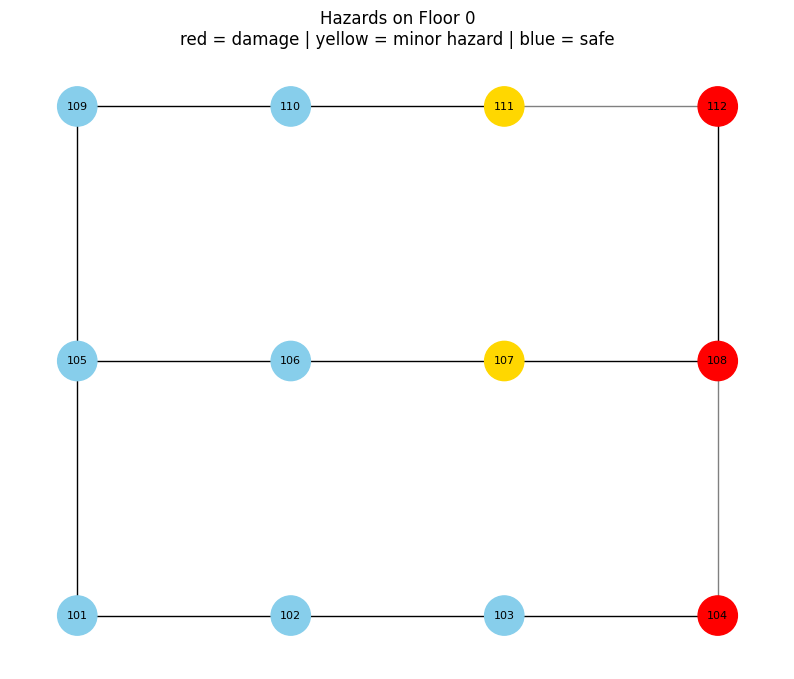

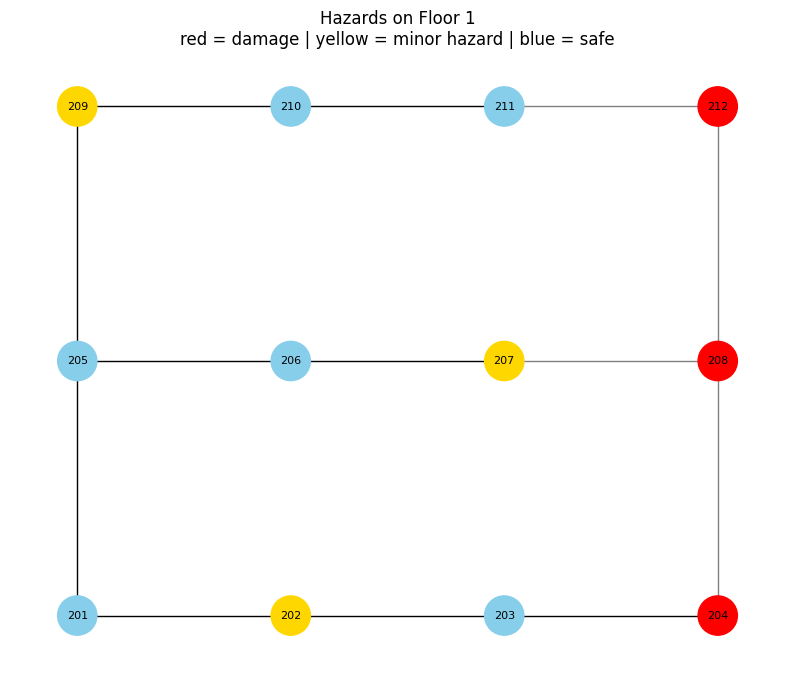

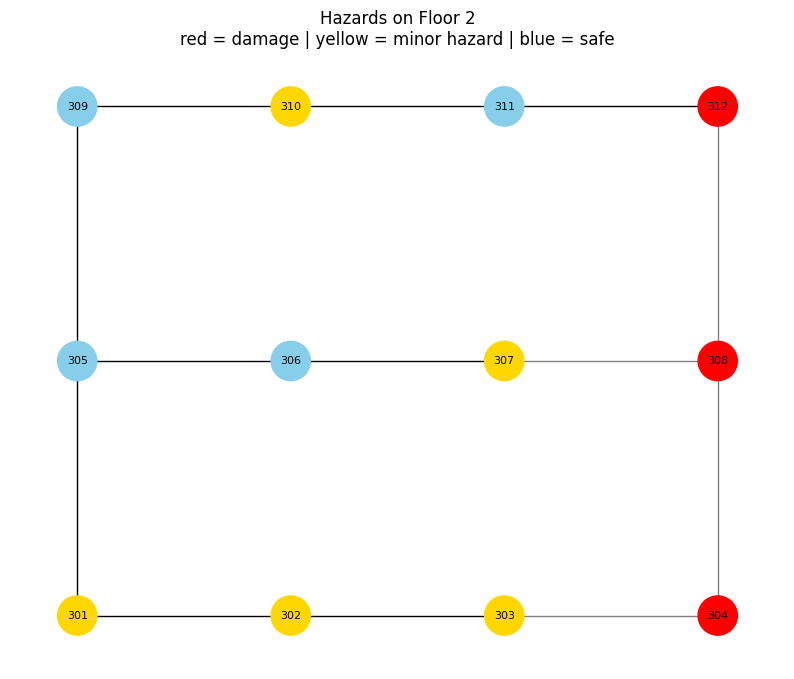

In [ ]:
def visualize_hazards_on_floor(G, z_level):
    plt.figure(figsize=(10, 8))

    # Get nodes on this floor
    floor_nodes = [n for n, d in G.nodes(data=True) if d["z"] == z_level * floor_spacing_z]
    pos = {n: (G.nodes[n]['x'], G.nodes[n]['y']) for n in floor_nodes}

    # Determine node color
    node_colors = []
    for n in floor_nodes:
        d = G.nodes[n]
        integrity = d.get("structural_integrity", 1.0)
        has_minor_hazard = any([
            d.get("glass_shards", False),
            d.get("obstruction", False),
            d.get("slippery", False),
            d.get("ceiling_damage", False)
        ])

        if integrity < 0.5:
            node_colors.append("red")      # major structural damage
        elif has_minor_hazard:
            node_colors.append("gold")     # minor hazard only
        else:
            node_colors.append("skyblue")  # safe room



    # Draw nodes
    nx.draw_networkx_nodes(G, pos, nodelist=floor_nodes, node_color=node_colors, node_size=800)
    nx.draw_networkx_labels(G, pos, labels={n: n for n in floor_nodes}, font_size=8)

    # Draw edges
    floor_edges = [(u, v) for u, v in G.edges() if u in floor_nodes and v in floor_nodes]
    edge_colors = ["gray" if G[u][v].get("status") == "blocked" else "black" for u, v in floor_edges]
    nx.draw_networkx_edges(G, pos, edgelist=floor_edges, edge_color=edge_colors)

    plt.title(f"Hazards on Floor {z_level}\nred = damage | yellow = minor hazard | blue = safe")
    plt.axis("off")
    plt.show()

for z in range(floors):
    visualize_hazards_on_floor(G, z)


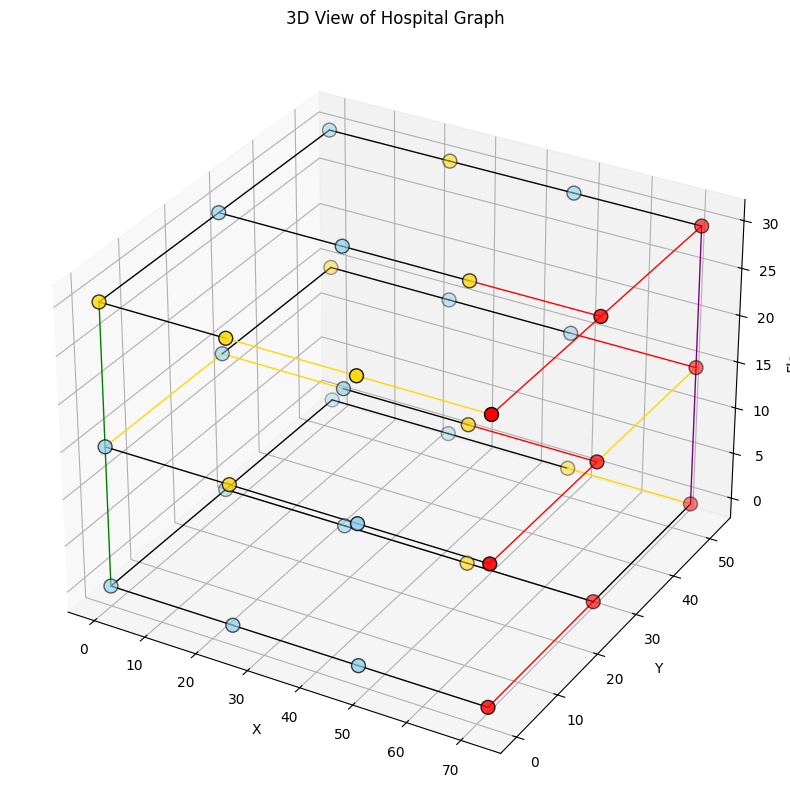

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

def visualize_hospital_3D(G):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Position of each node
    node_pos = {}
    xs, ys, zs, colors = [], [], [], []

    for n, d in G.nodes(data=True):
        if d.get("type") != "room":
            continue
        x, y, z = d["x"], d["y"], d["z"]
        node_pos[n] = (x, y, z)
        xs.append(x)
        ys.append(y)
        zs.append(z)

        integrity = d.get("structural_integrity", 1.0)
        has_minor_hazard = any([
            d.get("glass_shards", False),
            d.get("obstruction", False),
            d.get("slippery", False),
            d.get("ceiling_damage", False)
        ])

        if integrity < 0.5:
            colors.append("red")
        elif has_minor_hazard:
            colors.append("gold")
        else:
            colors.append("skyblue")

    # Draw nodes
    ax.scatter(xs, ys, zs, c=colors, s=100, edgecolors='k')

    # Draw edges
    for u, v, attr in G.edges(data=True):
        if u not in node_pos or v not in node_pos:
            continue
        x_vals = [node_pos[u][0], node_pos[v][0]]
        y_vals = [node_pos[u][1], node_pos[v][1]]
        z_vals = [node_pos[u][2], node_pos[v][2]]

        # Determine edge color strictly based on edge attributes
        if attr.get("hazard") == "debris":
            color = "gold"
        elif attr.get("status") == "blocked":
            color = "red"
        elif attr.get("edge_type") == "elevator":
            color = "green"
        elif attr.get("edge_type") == "stair":
            color = "purple"
        else:
            color = "black"

        ax.plot(x_vals, y_vals, z_vals, color=color, linewidth=1)



    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Floor")
    ax.set_title("3D View of Hospital Graph")
    plt.show()

# Run it
visualize_hospital_3D(G)
